# Task01
1.	Mahasiswa diminta untuk menjalankan dan menganalisis kode pada modul_praktikum_minggu_5 tutorial01.py
2.	Tugas individu ini bertujuan untuk memastikan setiap mahasiswa memahami dasar implementasi graph coloring.


Visualisasi Graf Sederhana:


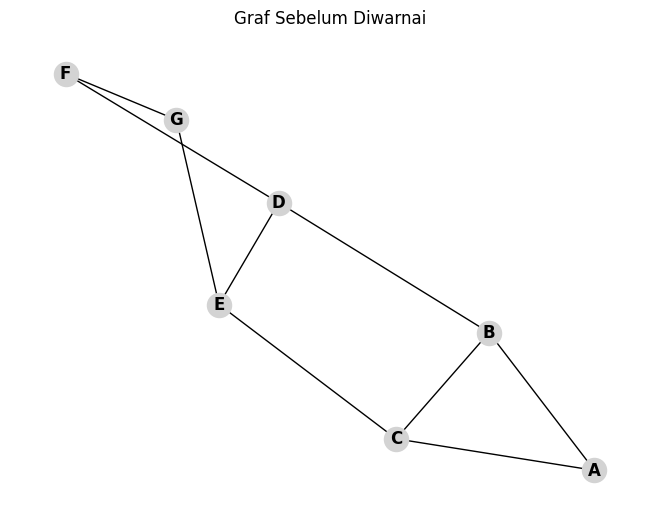


Hasil Pewarnaan Greedy:
{'B': 0, 'C': 1, 'D': 1, 'E': 0, 'A': 2, 'F': 0, 'G': 1}
Jumlah warna yang digunakan: 3

Visualisasi Graf Setelah Diwarnai:


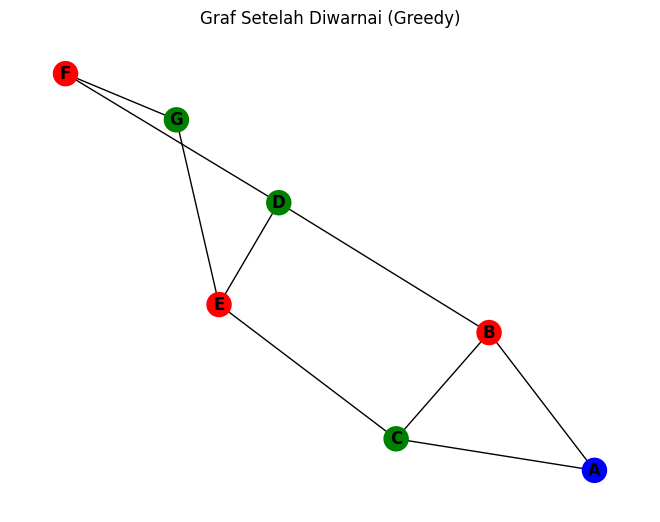


Hasil Pewarnaan Graf Bipartit:
{1: 0, 2: 0, 3: 0, 'a': 1, 'b': 1, 'c': 1}
Jumlah warna yang digunakan: 2


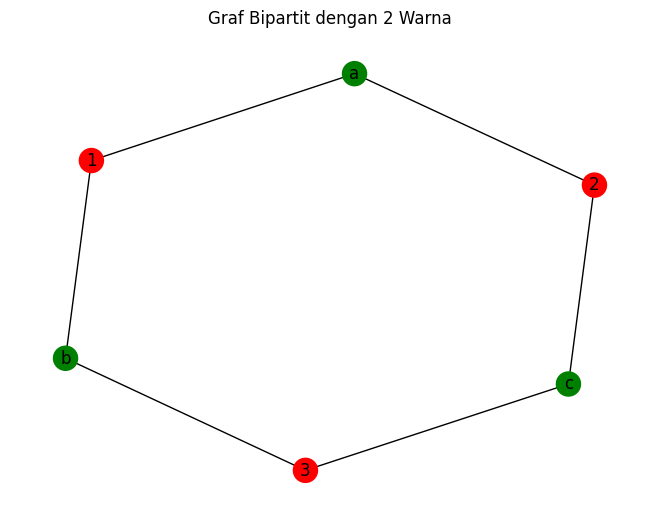

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Contoh Graf Sederhana ---
# Membuat graf sederhana
G = nx.Graph()
G.add_edges_from([
    ('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'),
    ('C', 'E'), ('D', 'E'), ('D', 'F'), ('E', 'G'),
    ('F', 'G')
])

# Visualisasi graf sebelum diwarnai
print("Visualisasi Graf Sederhana:")
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgrey', font_weight='bold')
plt.title("Graf Sebelum Diwarnai")
plt.show()

# --- 2. Menemukan Chromatic Number ---
# NetworkX tidak memiliki fungsi bawaan untuk Chromatic Number
# Ini adalah masalah NP-hard. Kita akan menggunakan library lain
# atau pendekatan heuristik jika diperlukan. Namun untuk kasus sederhana,
# kita bisa coba-coba (trial and error) atau menggunakan fungsi yang ada
# untuk mendapatkan pewarnaan yang valid.

# Mari kita coba untuk mewarnai graf secara heuristik (greedy coloring)
coloring = nx.coloring.greedy_color(G, strategy="largest_first")
print("\nHasil Pewarnaan Greedy:")
print(coloring)

# Mendapatkan jumlah warna unik (Chromatic Number heuristik)
num_colors = len(set(coloring.values()))
print(f"Jumlah warna yang digunakan: {num_colors}")

# --- 3. Visualisasi Hasil Pewarnaan ---
# Siapkan daftar warna untuk visualisasi
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange']
node_colors = [colors[coloring[node] % len(colors)] for node in G.nodes()]

print("\nVisualisasi Graf Setelah Diwarnai:")
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_weight='bold')
plt.title("Graf Setelah Diwarnai (Greedy)")
plt.show()

# --- 4. Memverifikasi Pewarnaan yang Valid ---
# Kita bisa memverifikasi secara manual.
# Misalkan ada edge ('D', 'F'). Simpul D dan F harus memiliki warna berbeda.
# Cek: coloring['D'] != coloring['F']

# Contoh untuk Graph yang Chromatic Number-nya sudah diketahui
# Graph Bipartite, Chromatic Number = 2
G_bipartite = nx.Graph()
G_bipartite.add_nodes_from([1, 2, 3], bipartite=0)
G_bipartite.add_nodes_from(['a', 'b', 'c'], bipartite=1)
G_bipartite.add_edges_from([(1, 'a'), (1, 'b'), (2, 'a'), (2, 'c'), (3, 'b'), (3, 'c')])

coloring_bipartite = nx.coloring.greedy_color(G_bipartite)
print("\nHasil Pewarnaan Graf Bipartit:")
print(coloring_bipartite)
num_colors_bipartite = len(set(coloring_bipartite.values()))
print(f"Jumlah warna yang digunakan: {num_colors_bipartite}")
nx.draw(G_bipartite, with_labels=True, node_color=[colors[coloring_bipartite[node]] for node in G_bipartite.nodes()])
plt.title("Graf Bipartit dengan 2 Warna")
plt.show()


# task02
 penjadwalan_rapat_proyek.py

-	Konsep yang diuji: Graph Coloring, Bipartite Graph, dan Chromatic Number
-	Skenario: Tim proyek Anda kini terdiri dari 6 developer: Alyn, Betty, Carol, David, Erin, dan Frank. Mereka memiliki keahlian yang tumpang tindih dan tidak bisa menghadiri rapat pada saat yang sama jika mereka berada di sub-tim yang sama.
-	Berikut adalah komposisi sub-tim:
    - Sub-tim 1: {Alyn, Betty, Erin}
    - Sub-tim 2: {Alyn, Carol, Frank}
    - Sub-tim 3: {Betty, David}
    - Sub-tim 4: {Carol, Erin, Frank}
    - Sub-tim 5: {David, Frank}
-	Tugas:
    - Modelkan masalah penjadwalan rapat ini sebagai sebuah graf. Simpul merepresentasikan sub-tim, dan sisi menghubungkan sub-tim yang memiliki anggota yang sama (sehingga tidak bisa dijadwalkan bersamaan).
    - Tentukan Chromatic Number (χ(G)) dari graf tersebut untuk mengetahui jumlah minimal slot waktu yang dibutuhkan.
    - Jelaskan bagaimana pemodelan ini mirip atau berbeda dari Bipartite Graph yang Anda kerjakan di minggu 2.


Hasil Pewarnaan untuk Penjadwalan Rapat:
{'Sub-tim 1': 0, 'Sub-tim 2': 1, 'Sub-tim 4': 2, 'Sub-tim 5': 0, 'Sub-tim 3': 1}
Jumlah minimal slot waktu yang dibutuhkan: 3

Visualisasi Graf Penjadwalan Rapat:


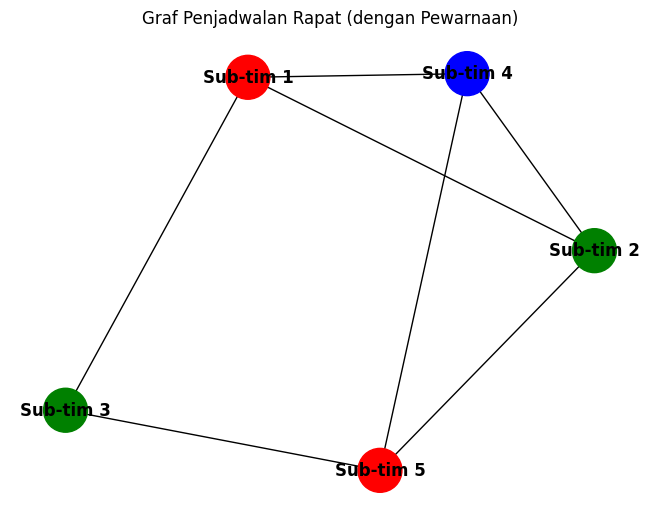


Penjelasan Hubungan dengan Bipartite Graph:
Pemodelan ini berbeda dari Bipartite Graph.
Graf Bipartit memiliki dua set simpul yang saling lepas, dan sisi hanya menghubungkan simpul dari satu set ke set lainnya.
Dalam masalah penjadwalan rapat ini, simpul merepresentasikan sub-tim, dan sisi merepresentasikan konflik (sub-tim berbagi anggota).
Tidak ada pembagian alami simpul menjadi dua set terpisah di mana tidak ada sisi dalam set tersebut.
Graf penjadwalan ini tidak harus bipartit; keberadaan siklus ganjil akan mencegahnya menjadi bipartit.
Chromatic Number dari graf ini langsung memberikan jumlah minimal slot waktu yang dibutuhkan, karena setiap slot waktu sesuai dengan satu warna, dan sub-tim yang memiliki warna yang sama dapat dijadwalkan bersamaan.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the sub-teams
sub_teams = {
    "Sub-tim 1": {"Alyn", "Betty", "Erin"},
    "Sub-tim 2": {"Alyn", "Carol", "Frank"},
    "Sub-tim 3": {"Betty", "David"},
    "Sub-tim 4": {"Carol", "Erin", "Frank"},
    "Sub-tim 5": {"David", "Frank"}
}

# Create a graph where nodes are sub-teams and edges connect sub-teams with shared members
G_scheduling = nx.Graph()

# Add nodes (sub-teams)
G_scheduling.add_nodes_from(sub_teams.keys())

# Add edges based on shared members
edges_to_add = []
team_names = list(sub_teams.keys())
for i in range(len(team_names)):
    for j in range(i + 1, len(team_names)):
        team1_name = team_names[i]
        team2_name = team_names[j]
        # Check for shared members (intersection of sets)
        if sub_teams[team1_name].intersection(sub_teams[team2_name]):
            edges_to_add.append((team1_name, team2_name))

G_scheduling.add_edges_from(edges_to_add)

# --- Graph Coloring to find minimum time slots ---
# Use greedy coloring as an approximation for chromatic number
scheduling_coloring = nx.coloring.greedy_color(G_scheduling, strategy="largest_first")

print("Hasil Pewarnaan untuk Penjadwalan Rapat:")
print(scheduling_coloring)

# Get the number of unique colors (minimum time slots)
num_time_slots = len(set(scheduling_coloring.values()))
print(f"Jumlah minimal slot waktu yang dibutuhkan: {num_time_slots}")

# --- Visualization of the scheduling graph ---
print("\nVisualisasi Graf Penjadwalan Rapat:")
pos_scheduling = nx.spring_layout(G_scheduling, seed=42)
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'cyan', 'magenta'] # More colors in case needed
node_colors_scheduling = [colors[scheduling_coloring[node] % len(colors)] for node in G_scheduling.nodes()]

nx.draw(G_scheduling, pos_scheduling, with_labels=True, node_color=node_colors_scheduling, font_weight='bold', node_size=1000)
plt.title("Graf Penjadwalan Rapat (dengan Pewarnaan)")
plt.show()

# --- Explanation of the relationship with Bipartite Graphs ---
print("\nPenjelasan Hubungan dengan Bipartite Graph:")
print("Pemodelan ini berbeda dari Bipartite Graph.")
print("Graf Bipartit memiliki dua set simpul yang saling lepas, dan sisi hanya menghubungkan simpul dari satu set ke set lainnya.")
print("Dalam masalah penjadwalan rapat ini, simpul merepresentasikan sub-tim, dan sisi merepresentasikan konflik (sub-tim berbagi anggota).")
print("Tidak ada pembagian alami simpul menjadi dua set terpisah di mana tidak ada sisi dalam set tersebut.")
print("Graf penjadwalan ini tidak harus bipartit; keberadaan siklus ganjil akan mencegahnya menjadi bipartit.")
print("Chromatic Number dari graf ini langsung memberikan jumlah minimal slot waktu yang dibutuhkan, karena setiap slot waktu sesuai dengan satu warna, dan sub-tim yang memiliki warna yang sama dapat dijadwalkan bersamaan.")

# task03
Task03_Alokasi Frekuensi Radio.py

-	Konsep yang diuji: Graph Coloring, Connected Components, dan Cut Vertex
-	Skenario: Sebuah perusahaan telekomunikasi memiliki 8 stasiun pemancar radio (A, B, C, D, E, F, G, H) di sebuah kota. Aturan pemerintah menyatakan bahwa stasiun-stasiun yang berdekatan tidak boleh menggunakan frekuensi yang sama untuk menghindari interferensi. Jarak antar stasiun adalah sebagai berikut (jarak < 10 km dianggap berdekatan):
    - A berdekatan dengan B, C
    - B berdekatan dengan A, D
    - C berdekatan dengan A, E
    - D berdekatan dengan B, F
    - E berdekatan dengan C, G
    - F berdekatan dengan D, H
    - G berdekatan dengan E, H
    - H berdekatan dengan F, G
-	Tugas:
    - Modelkan masalah ini sebagai graf tak berarah, di mana simpul adalah stasiun dan sisi menghubungkan stasiun yang berdekatan.
    - Tentukan Chromatic Number (χ(G)) dari graf tersebut. Visualisasikan graf dengan pewarnaan yang sesuai.
    - Identifikasi Cut Vertex mana pun yang mungkin ada di graf. Jika ada, jelaskan mengapa Cut Vertex ini merupakan titik krusial dalam jaringan.


Hasil Pewarnaan untuk Alokasi Frekuensi:
{'A': 0, 'B': 1, 'C': 1, 'D': 0, 'E': 0, 'F': 1, 'G': 1, 'H': 0}
Jumlah minimal frekuensi yang dibutuhkan: 2

Visualisasi Graf Alokasi Frekuensi:


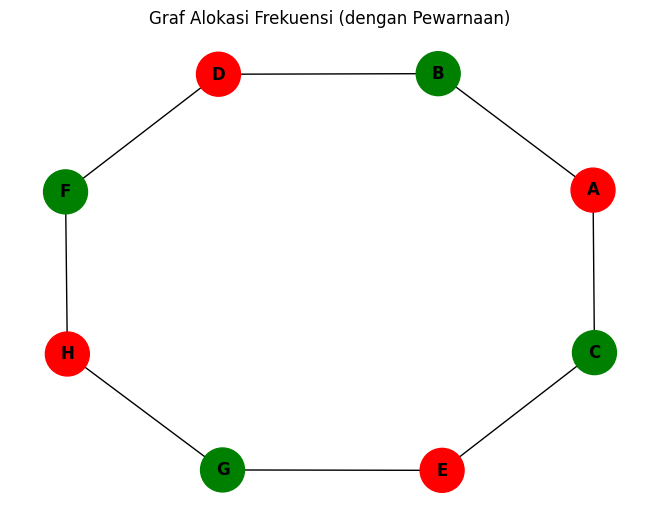


Identifikasi Cut Vertex:
Tidak ada Cut Vertex dalam graf ini.


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the stations and their adjacencies (distance < 10 km)
# This can be directly represented as edges in a graph
adjacencies = [
    ('A', 'B'), ('A', 'C'),
    ('B', 'A'), ('B', 'D'),
    ('C', 'A'), ('C', 'E'),
    ('D', 'B'), ('D', 'F'),
    ('E', 'C'), ('E', 'G'),
    ('F', 'D'), ('F', 'H'),
    ('G', 'E'), ('G', 'H'),
    ('H', 'F'), ('H', 'G')
]

# Create an undirected graph
G_radio = nx.Graph()

# Add nodes (stations)
stations = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
G_radio.add_nodes_from(stations)

# Add edges based on adjacencies
G_radio.add_edges_from(adjacencies)

# --- Graph Coloring to find minimum frequencies ---
# Use greedy coloring as an approximation for chromatic number
radio_coloring = nx.coloring.greedy_color(G_radio, strategy="largest_first")

print("Hasil Pewarnaan untuk Alokasi Frekuensi:")
print(radio_coloring)

# Get the number of unique colors (minimum frequencies)
num_frequencies = len(set(radio_coloring.values()))
print(f"Jumlah minimal frekuensi yang dibutuhkan: {num_frequencies}")

# --- Visualization of the radio station graph ---
print("\nVisualisasi Graf Alokasi Frekuensi:")
pos_radio = nx.spring_layout(G_radio, seed=42)
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'cyan', 'magenta'] # More colors in case needed
node_colors_radio = [colors[radio_coloring[node] % len(colors)] for node in G_radio.nodes()]

nx.draw(G_radio, pos_radio, with_labels=True, node_color=node_colors_radio, font_weight='bold', node_size=1000)
plt.title("Graf Alokasi Frekuensi (dengan Pewarnaan)")
plt.show()

# --- Identify Cut Vertices ---
# Cut vertices are nodes whose removal increases the number of connected components
cut_vertices = list(nx.articulation_points(G_radio))

print("\nIdentifikasi Cut Vertex:")
if cut_vertices:
    print(f"Cut Vertices: {cut_vertices}")
    print("Penjelasan: Cut Vertex adalah titik krusial dalam jaringan karena jika stasiun pada titik ini nonaktif atau mengalami masalah, jaringan komunikasi dapat terpecah menjadi komponen-komponen yang terputus.")
    print("Dalam konteks alokasi frekuensi, jika stasiun pada cut vertex bermasalah, komunikasi antar beberapa stasiun lain yang sebelumnya terhubung melaluinya bisa terganggu.")
else:
    print("Tidak ada Cut Vertex dalam graf ini.")

# task04
Task04_Rute Kurir dan Kendala Ruang Penyimpanan.py

-	Konsep yang diuji: Graph Coloring, Euler Path/Circuit, dan Alokasi Sumber Daya
-	Skenario: Seorang kurir harus melewati setiap jalan di 6 area (A, B, C, D, E, F) tepat satu kali. Namun, setiap area hanya memiliki satu jenis loker, dan paket untuk area yang berdekatan tidak boleh disimpan di loker yang sama.
-	Tugas:
    -	Modelkan rute kurir ini sebagai graf tak berarah.
    - Periksa apakah graf tersebut memiliki Euler Circuit atau Euler Path. Jelaskan mengapa.
    -	Modelkan masalah alokasi loker menggunakan Graph Coloring. Tentukan Chromatic Number (χ(G)) dari graf tersebut untuk mengetahui jumlah minimal jenis loker yang dibutuhkan.
    - Jelaskan hubungan antara keberadaan Euler Circuit dan Graph Coloring pada masalah ini.


Visualisasi Graf Rute Kurir:


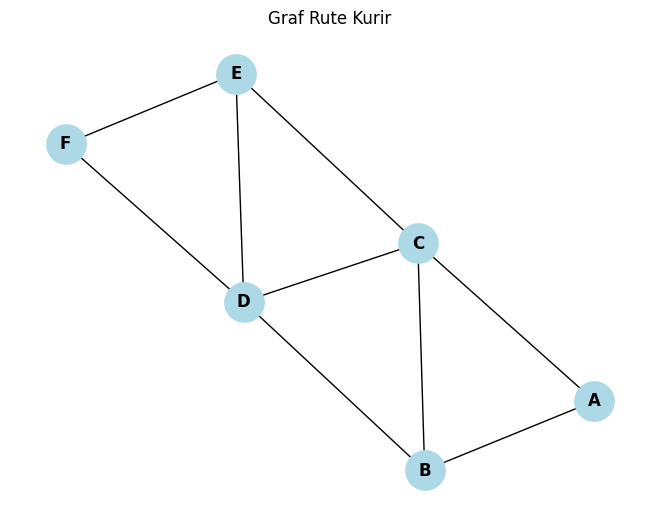


Pemeriksaan Euler Path/Circuit:
Graf terhubung: True
Derajat simpul: {'A': 2, 'B': 3, 'C': 4, 'D': 4, 'E': 3, 'F': 2}
Simpul dengan derajat ganjil: ['B', 'E']
Tepat dua simpul memiliki derajat ganjil. Graf ini memiliki Euler Path.
Kurir harus memulai rutenya di salah satu simpul derajat ganjil (B atau E) dan mengakhirinya di simpul derajat ganjil lainnya.
Setiap jalan akan dilewati tepat satu kali.

Alokasi Loker menggunakan Pewarnaan Graf:
Hasil Pewarnaan untuk Alokasi Loker:
{'C': 0, 'D': 1, 'B': 2, 'E': 2, 'A': 1, 'F': 0}
Jumlah minimal jenis loker yang dibutuhkan: 3

Visualisasi Graf Alokasi Loker:


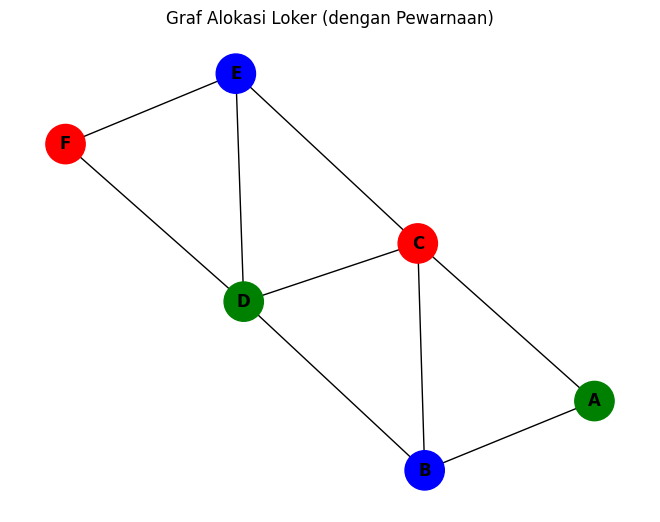


Hubungan antara Euler Circuit dan Graph Coloring:
Kedua konsep (Euler Path/Circuit dan Graph Coloring) menangani aspek yang berbeda dari graf yang sama (graf rute kurir).
- Euler Path/Circuit berkaitan dengan traversability graf, yaitu apakah mungkin untuk mengunjungi setiap sisi (jalan) tepat satu kali.
- Graph Coloring berkaitan dengan pewarnaan simpul (area) sedemikian rupa sehingga simpul yang berdekatan memiliki warna (jenis loker) yang berbeda. Ini adalah masalah alokasi sumber daya untuk menghindari konflik.
Dalam masalah ini:
  - Ada atau tidaknya Euler Path/Circuit menentukan apakah kurir dapat menyelesaikan tugasnya melewati setiap jalan hanya sekali.
  - Chromatic Number menentukan berapa banyak jenis loker yang berbeda yang diperlukan untuk menyimpan paket di area yang berdekatan tanpa konflik.
Kedua konsep ini independen satu sama lain dalam arti bahwa keberadaan Euler Path/Circuit tidak secara langsung menentukan Chromatic Number, dan sebaliknya. Namun, keduanya mengguna

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the areas and the paths (streets) connecting them
# Assuming the connections represent streets the courier must travel
# Let's create a graph based on possible connections between areas A-F
# The problem states the courier must pass through EVERY street exactly once.
# This implies an Euler Path or Circuit problem.
# We need to define the graph based on the streets. Let's interpret the areas
# as nodes and the connections between them as edges. The description doesn't
# explicitly list the streets, so we'll create a plausible set of connections
# that might represent streets a courier would traverse in these areas.
# If the areas are nodes, the streets are edges. To traverse every street
# exactly once, we need an Eulerian path or circuit.

# Let's assume a graph structure where areas are connected as follows:
# A connected to B, C
# B connected to A, C, D
# C connected to A, B, D, E
# D connected to B, C, E, F
# E connected to C, D, F
# F connected to D, E
# This is just one possible interpretation of the connections. The actual graph
# depends on the specific streets the courier must cover.
# However, for the purpose of demonstrating the concepts (Euler Path/Circuit and Coloring),
# we'll use this example graph.

# Create an undirected graph for the courier route
G_courier = nx.Graph()

# Add nodes (areas)
areas = ['A', 'B', 'C', 'D', 'E', 'F']
G_courier.add_nodes_from(areas)

# Add edges (streets/connections) based on the assumed structure
# A-B, A-C
# B-C, B-D
# C-D, C-E
# D-E, D-F
# E-F
edges_courier = [
    ('A', 'B'), ('A', 'C'),
    ('B', 'C'), ('B', 'D'),
    ('C', 'D'), ('C', 'E'),
    ('D', 'E'), ('D', 'F'),
    ('E', 'F')
]
G_courier.add_edges_from(edges_courier)

print("Visualisasi Graf Rute Kurir:")
pos_courier = nx.spring_layout(G_courier, seed=42)
nx.draw(G_courier, pos_courier, with_labels=True, node_color='lightblue', font_weight='bold', node_size=800)
plt.title("Graf Rute Kurir")
plt.show()


# --- Check for Euler Path or Circuit ---
print("\nPemeriksaan Euler Path/Circuit:")

# An undirected graph has an Euler circuit if and only if every vertex
# has even degree, and all vertices with nonzero degree belong to a single
# connected component.
# An undirected graph has an Euler path if and only if at most two vertices
# have odd degree, and all vertices with nonzero degree belong to a single
# connected component.

is_connected = nx.is_connected(G_courier)
print(f"Graf terhubung: {is_connected}")

degrees = dict(G_courier.degree())
print(f"Derajat simpul: {degrees}")

odd_degree_vertices = [node for node, degree in degrees.items() if degree % 2 != 0]
print(f"Simpul dengan derajat ganjil: {odd_degree_vertices}")

if not is_connected and len(G_courier.nodes()) > 1:
     print("Graf tidak terhubung, tidak mungkin memiliki Euler Path atau Circuit.")
elif not odd_degree_vertices:
    print("Semua simpul memiliki derajat genap. Graf ini memiliki Euler Circuit.")
    print("Kurir dapat memulai dan mengakhiri rutenya di simpul yang sama, melewati setiap jalan tepat satu kali.")
elif len(odd_degree_vertices) == 2:
    print("Tepat dua simpul memiliki derajat ganjil. Graf ini memiliki Euler Path.")
    print(f"Kurir harus memulai rutenya di salah satu simpul derajat ganjil ({odd_degree_vertices[0]} atau {odd_degree_vertices[1]}) dan mengakhirinya di simpul derajat ganjil lainnya.")
    print("Setiap jalan akan dilewati tepat satu kali.")
else:
    print("Lebih dari dua simpul memiliki derajat ganjil. Graf ini tidak memiliki Euler Path atau Circuit.")
    print("Kurir tidak dapat melewati setiap jalan tepat satu kali.")


# --- Locker Allocation using Graph Coloring ---
# The areas (nodes) are colored such that adjacent areas (connected by an edge)
# do not have the same color (locker type).
# The chromatic number gives the minimum number of locker types needed.

print("\nAlokasi Loker menggunakan Pewarnaan Graf:")

# Use greedy coloring as an approximation for chromatic number
locker_coloring = nx.coloring.greedy_color(G_courier, strategy="largest_first")

print("Hasil Pewarnaan untuk Alokasi Loker:")
print(locker_coloring)

# Get the number of unique colors (minimum locker types)
num_locker_types = len(set(locker_coloring.values()))
print(f"Jumlah minimal jenis loker yang dibutuhkan: {num_locker_types}")

# Visualisasi Graf Alokasi Loker
print("\nVisualisasi Graf Alokasi Loker:")
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange']
node_colors_locker = [colors[locker_coloring[node] % len(colors)] for node in G_courier.nodes()]

nx.draw(G_courier, pos_courier, with_labels=True, node_color=node_colors_locker, font_weight='bold', node_size=800)
plt.title("Graf Alokasi Loker (dengan Pewarnaan)")
plt.show()


# --- Relationship between Euler Circuit and Graph Coloring ---
print("\nHubungan antara Euler Circuit dan Graph Coloring:")
print("Kedua konsep (Euler Path/Circuit dan Graph Coloring) menangani aspek yang berbeda dari graf yang sama (graf rute kurir).")
print("- Euler Path/Circuit berkaitan dengan traversability graf, yaitu apakah mungkin untuk mengunjungi setiap sisi (jalan) tepat satu kali.")
print("- Graph Coloring berkaitan dengan pewarnaan simpul (area) sedemikian rupa sehingga simpul yang berdekatan memiliki warna (jenis loker) yang berbeda. Ini adalah masalah alokasi sumber daya untuk menghindari konflik.")
print("Dalam masalah ini:")
print("  - Ada atau tidaknya Euler Path/Circuit menentukan apakah kurir dapat menyelesaikan tugasnya melewati setiap jalan hanya sekali.")
print("  - Chromatic Number menentukan berapa banyak jenis loker yang berbeda yang diperlukan untuk menyimpan paket di area yang berdekatan tanpa konflik.")
print("Kedua konsep ini independen satu sama lain dalam arti bahwa keberadaan Euler Path/Circuit tidak secara langsung menentukan Chromatic Number, dan sebaliknya. Namun, keduanya menggunakan struktur graf yang sama untuk memodelkan kendala dan persyaratan dalam skenario kurir dan loker.")